In [64]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

In [65]:
#loading the MNIST Fashion Dataset
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

In [66]:
# Number of training images : 60000
x_train.shape

(60000, 28, 28)

In [67]:
x_test.shape #10,000 images for testing purpose with 28x28 dimention

(10000, 28, 28)

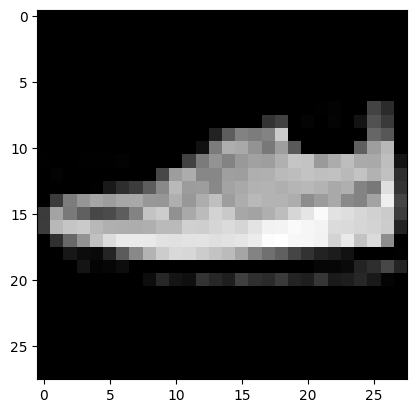

In [68]:

#visualizing a sample image from the data
plt.imshow(x_train[437],cmap='gray')

In [69]:

#Nomalize the pixel values between 0-1
x_train_norm=x_train.astype('float32')/255.0 #all the 60k images are getting normalized
x_test_norm=x_test.astype('float32')/255.0 #all the 10k images are getting normalized

In [70]:
x_train_norm.max()

np.float32(1.0)

In [71]:
sample_pixel=x_train_norm[1125]

In [72]:
sample_pixel[:,]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.01960784, 0.00784314, 0.        ,
        0.        , 0.18431373, 0.5176471 , 0.5686275 , 0.5686275 ,
        0.40784314, 0.23921569, 0.04705882, 0.        , 0.        ,
        0.01568628, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.15686275,
        0.37254903, 0.38039216, 0.48235294, 0.4745098 , 0.42745098,
        0.44705883, 0.50980395, 0.4117647 , 0.5176471 , 0.        ,
        0.        , 0.00784314, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.16862746, 0.6431373 , 0.8901961 ,
        0.62352943, 0.38039216, 0.1882353 , 0.2784314 , 0.31764707,
        0.36862746, 0.3764

In [73]:
demo_conv=layers.Conv2D(filters=4,kernel_size=(3,3),activation='relu')
demo_pool=layers.MaxPool2D(pool_size=(2,2))
x_train_norm = np.expand_dims(x_train_norm, axis=-1)
x_test_norm = np.expand_dims(x_test_norm, axis=-1)
conv_output=demo_conv(x_train_norm)
pool_output=demo_pool(conv_output)

In [74]:
conv_output.shape

TensorShape([60000, 26, 26, 4])

In [75]:
pool_output.shape

TensorShape([60000, 13, 13, 4])

In [76]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

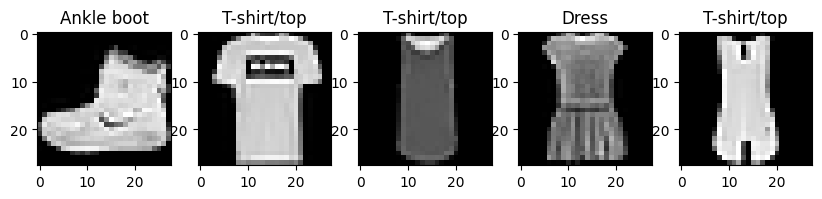

In [77]:
plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])

plt.show()

In [78]:

#Building the CNN Image Classifier
model=models.Sequential([
    layers.Input(shape=(28,28,1),
                 name="input_layer"),
    layers.Conv2D(filters=16,activation='relu',kernel_size=(3,3),
                  name="conv_layer_1"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_1"),#[1,13,13,16]
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',
                  name="conv_layer_2"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_2"),#[1,5,5,32]
    layers.Flatten(name="flatten_layer"), #5x5x32 = 800 values
    layers.Dense(64,activation='relu',name="hidden_layer_1"),
    layers.Dense(32,activation='relu',name="hidden_layer_2"),
    layers.Dense(units=10,activation='softmax',name="output_layer")
])

In [79]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,474 (228.41 KB)

 Trainable params: 58,474 (228.41 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [81]:
model.fit(x_train_norm,y_train,epochs=20,batch_size=32)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.8118 - loss: 0.5188
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8776 - loss: 0.3392
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.8934 - loss: 0.2923
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9033 - loss: 0.2638
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9097 - loss: 0.2432
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9175 - loss: 0.2237
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9225 - loss: 0.2083
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9276 - loss: 0.1960
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9323 - loss: 0.1820
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9353 - loss: 0.1718
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9387 - loss: 0.1642
Epoch 12

In [82]:
# Test Accuracy
test_loss,test_accuracy=model.evaluate(x_test_norm,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8989 - loss: 0.3706


In [83]:
predictions = model.predict(x_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [84]:
print(predictions.shape)

(10000, 10)


In [85]:
predicted_labels = np.argmax(predictions, axis=1)

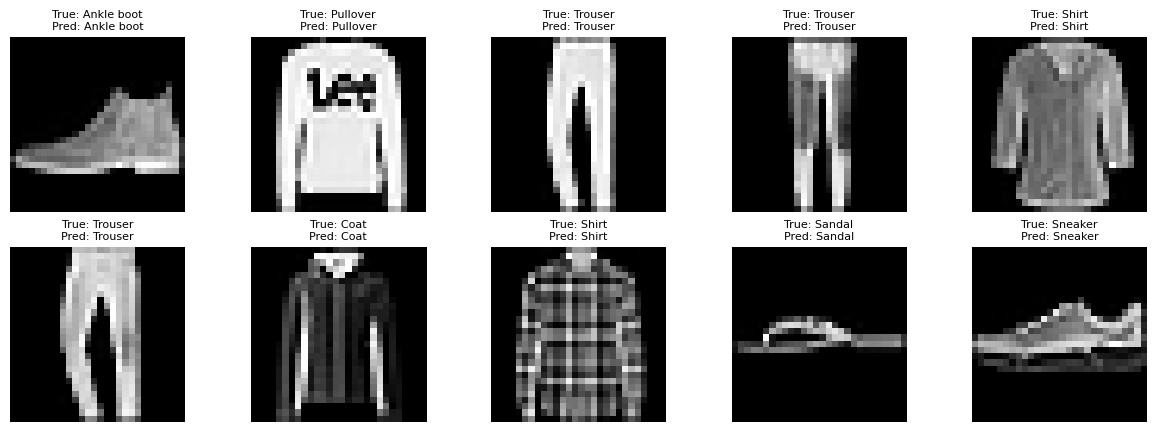

In [86]:
#  Display the predicted class labels for at least 10 test images.
plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(
        f"True: {class_names[y_test[i]]}\nPred: {class_names[predicted_labels[i]]}",
        fontsize=8
    )
    plt.axis('off')

plt.show()

In [87]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, predicted_labels)

confusion_df = pd.DataFrame(
    confusion,
    index=class_names,
    columns=class_names
)

print(confusion_df)

             T-shirt/top  Trouser  Pullover  Dress  Coat  Sandal  Shirt  \
T-shirt/top          881        0        24     10     1       1     77   
Trouser                6      982         2      7     1       0      1   
Pullover              15        1       896      9    21       0     56   
Dress                 20       19        12    893    15       0     40   
Coat                   1        1        99     33   782       0     84   
Sandal                 2        0         0      0     0     981      0   
Shirt                128        1        72     21    42       0    726   
Sneaker                0        0         0      1     0      32      0   
Bag                    3        1         4      4     2       3      3   
Ankle boot             0        0         0      0     0       5      0   

             Sneaker  Bag  Ankle boot  
T-shirt/top        0    6           0  
Trouser            0    1           0  
Pullover           0    2           0  
Dress         

In [88]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.88      0.86      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.81      0.90      0.85      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.91      0.78      0.84      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt       0.74      0.73      0.73      1000
     Sneaker       0.98      0.89      0.93      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.92      0.98      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



# **1. Why CNNs are better than Artificial Neural Networks (ANNs) for image classification?**

CNNs are designed specifically for image data. They automatically learn important visual features like edges, shapes, textures and patterns using convolutional filters. CNNs are more efficient and accurate than ANNs in image classification tasks because they maintain the spatial relationship between pixels and have significantly fewer trainable parameters.

# **2. What is the purpose of a Convolution layer?**

The convolution layer is the main feature extraction layer of CNN. It uses small filters (kernels) on the input image to extract features like edges, corners, textures and shapes. As the network gets deeper it learns more complex features that help distinguish between the different classes of images.

# **3. Why is Max Pooling used in CNNs?**


Max Pooling is a down-sampling operation that chooses the maximum value in each small region of the feature maps. It reduces computational cost, increases the speed of training, and enables the model to concentrate on the most salient features and mitigates overfitting.

# **4.Why is the Flatten layer required before the Dense layers?**

After the convolution and pooling layers, the data is still in a multi-dimensional format (height × width × channels). Dense (fully connected) layers require a one-dimensional input. The Flatten layer converts the multi-dimensional feature maps into a single vector so that they can be processed by the Dense layers.

# **5. Why is the Softmax activation function used in the output layer?**

Softmax converts the output values into probabilities for each class. The probabilities sum to 1, making it easy to identify the class with the highest probability as the model's prediction.


# **6. How does the Adam optimizer help in training the CNN?**

Adam (Adaptive Moment Estimation) automatically adjusts the learning rate for each parameter during training. It combines the benefits of momentum and adaptive learning rates, resulting in faster convergence, more stable training, and better performance than standard gradient descent in many cases.